# **Diplomado IA: Inteligencia Artificial I - Parte 1**. <br> Práctico 13.3: Seq2Seq y Mecanismos de Atención
---
---

**Profesores:**
- Gabriel Sepúlveda

**Ayudante:**
-
---
---

# **Instrucciones Generales**

El siguiente práctico se debe realizar de forma individual. El formato de entrega es el **archivo .ipynb con todas las celdas ejecutadas**, en el cual deberá completar las actividades propuestas.

**Fecha de entrega:** domingo 7 de diciembre de 2025, 23:59 hrs.

**Nombre alumno:**

In [ ]:
!pip install torchtext==0.6.0

# Import Base Dependencies

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
try:
    from tqdm.notebook import tqdm, trange
except:
    from tqdm import tqdm, trange

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchtext import data, datasets, vocab

In [ ]:
# for reproducibility
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using {DEVICE}')

# General Utilities

In [ ]:
def num_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Sequence to sequence (seq2seq): Translation

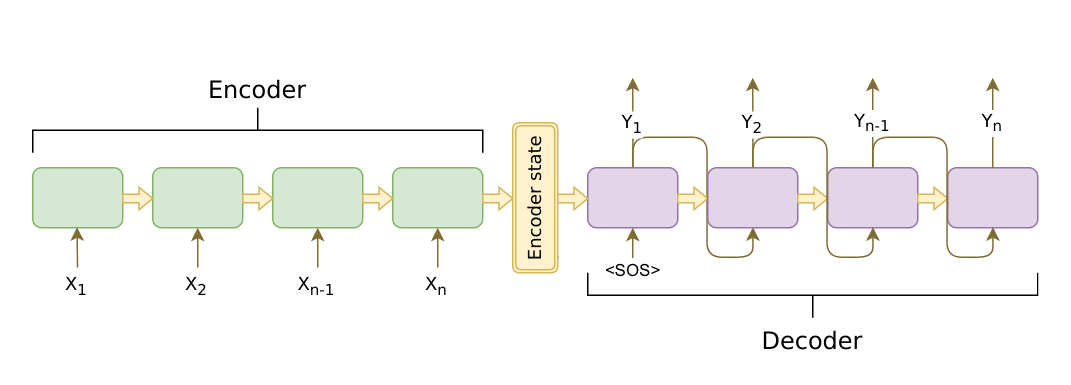

based on [tutorials.pytorch](https://jeddy92.github.io/JEddy92.github.io/ts_seq2seq_intro/)

## Encoder

Pretty much the same encoder as in the first part (sentiment analysis).
We embedd the input words and then pass them through a bi-directional LSTM.
The last hidden-state will be used to condition the decoder on the input sequence.

In [ ]:
class EncoderModule(nn.Module):
    def __init__(self, embedding_size, hidden_size, source_vocab_size):
        super().__init__()
        self.embeddings_table = nn.Embedding(source_vocab_size,
                                             embedding_size,
                                             padding_idx=0)
        self.embedding_size = embedding_size
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size=embedding_size,
                            hidden_size=hidden_size,
                            bidirectional=True,
                            batch_first=True)

    # forward pass
    def forward(self, src_sentences):
        """
        src_sentences shape (batch, seq_len)
        """
        # embed input sequences (batch, seq_len, embed_size)
        embedded = self.embeddings_table(src_sentences)

        # run lstm on full input sequence Tuple(Tensor, Tensor)
        _, hidden_state = self.lstm(embedded)

        return hidden_state

## Decoder

- In order to decode multiple words we will predict one word at a time using a LSTM cell.
  In **pseudo-code**:

    ~~~python
    predicted_words = []
    for word_idx in range(max_output_len):
        prediction = model.predict()
        predicted_words.append(prediction)

    return predicted_words
    ~~~

- To condition the decoder on the input sequence we will use the last hidden-state of the encoder as the first hidden-state of the decoder.

### <b><u>TEACHER FORCING</u></b>

Before the decoder received the last predicted word as input.
However, this time we will do this differently:
- during **training** we will use the correct word rather than the prediction.
  This is called **teacher forcing** and helps with convergence times.
- during **evaluation/test** we use the models prediction.

As before, the first iteration will receive a special `<SOS>` (start of sentence) token.

In [ ]:
class DecoderModule(nn.Module):
    def __init__(self, embedding_size, hidden_size, start_idx, dst_vocab_size):
        super().__init__()
        self.embeddings_table = nn.Embedding(dst_vocab_size,
                                             embedding_size,
                                             padding_idx=0)
        self.start_idx = torch.tensor(start_idx).to(DEVICE)
        self.hidden_size = hidden_size

        self.h2o = torch.nn.Linear(hidden_size, dst_vocab_size)
        self.lstm_cell = torch.nn.LSTMCell(input_size=embedding_size,
                                           hidden_size=hidden_size)

    # forward pass
    def forward(self, encoder_hidden_state, max_output_length, correct_answer=None):
        """
        encoder_hidden_state: Tuple(
            Tensor: (batch, hidden_size)
            Tensor: (batch, hidden_size)
        )
        max_output_length: int

        returns Tensor: (batch, max_output_length, dst_vocab_size)
        """
        batch_size = encoder_hidden_state[0].shape[0]

        out = []
        # initial decoder hidden state is final encoder hidden state
        state = encoder_hidden_state

        # decoding loop (decode one output word at a time)
        y_t = self.embeddings_table(self.start_idx.repeat(batch_size))
        for i in range(max_output_length):
            state  = self.lstm_cell(y_t, state)

            # calculate output probs (batch, dst_vocab_size)
            P_t = self.h2o(state[0])
            out.append(P_t)

            if self.training:
                # teacher forcing during training
                y_t = self.embeddings_table(correct_answer[:,i])
            else:
                # run as normal
                _, max_indices = P_t.max(dim=1) # (valor, indice)
                y_t = self.embeddings_table(max_indices)

        return torch.stack(out, dim=1)

## Data

SCAN dataset ([link](https://github.com/brendenlake/SCAN))

Translates english commands to robot actions:

| Input |   | Output |
| --- | --- | --- |
| jump	|| JUMP |
| jump left	|| LTURN JUMP|
| jump around right	|| RTURN JUMP RTURN JUMP RTURN JUMP RTURN JUMP |


### Download dataset

In [ ]:
import requests

BASE_PATH = 'https://gist.githubusercontent.com/ceyzaguirre4/707273ad9fc1729ebe2daac442a8f5a8/raw/'

def download_scan(split):
    filename = f'{split}.txt'
    url = BASE_PATH + filename
    response = requests.get(url)

    with open(filename, 'w') as out_file:
        out_file.write(response.text)

download_scan('tasks_test_simple')
download_scan('tasks_train_simple')

In [ ]:
!head tasks_test_simple.txt

### Load data

In [ ]:
# convert text into tokens
def tokenize(text):
    return text.strip().lower().split()

In [ ]:
SOURCE = data.Field(tokenize=tokenize, unk_token=None, batch_first=True)
TARGET = data.Field(tokenize=tokenize, unk_token=None, batch_first=True)

train, test = data.TabularDataset.splits(".",
                                         train="tasks_train_simple.txt",
                                         test="tasks_test_simple.txt",
                                         format="tsv",
                                         fields=[
                                                 ("source", SOURCE),
                                                 ("target", TARGET)],
                                         skip_header=False)

SOURCE.build_vocab(train)
TARGET.build_vocab(train)

train_iter, test_iter = data.BucketIterator.splits((train, test),
                                                   batch_sizes=(128, 128),
                                                   device=DEVICE,
                                                   sort_key=lambda x: len(x.target))

## Train Utils

In [ ]:
def train_one_epoch(model, dataloader, optimizer, history):
    model.train()
    for batch in dataloader:
        # forward pass
        y_gt = batch.target
        batch_size, max_ouput_len = batch.target.shape
        y_pred = model(batch.source, max_ouput_len, y_gt)

        loss = F.cross_entropy(y_pred.flatten(end_dim=-2),
                               y_gt.view(-1))

        history['train_loss'].append(loss.item())

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [ ]:
def eval_one_epoch(model, dataloader, optimizer, history):
    model.eval()
    history['eval_acc'].append(0)
    history['eval_loss'].append(0)
    with torch.no_grad():
        for batch in dataloader:
            # forward pass
            y_gt = batch.target
            batch_size, max_ouput_len = batch.target.shape
            y_pred = model(batch.source, max_ouput_len)

            loss = F.cross_entropy(y_pred.flatten(end_dim=-2),
                                y_gt.view(-1))
            accuracy = (y_pred.argmax(dim=2) == y_gt).float().mean()

            history['eval_acc'][-1] += (accuracy / len(dataloader)).item()
            history['eval_loss'][-1] += (loss / len(dataloader)).item()

In [ ]:
def train_model(model, train_dataloader, test_dataloader, optimizer, epochs):
    history = defaultdict(list)
    for epoch in trange(epochs):
        train_one_epoch(model, train_dataloader, optimizer, history)
        eval_one_epoch(model, test_dataloader, optimizer, history)
    return history

## Full Model

In [ ]:
class SeqToSeq(nn.Module):
    def __init__(self, embedding_size, hidden_size, source_vocab_size, dest_vocab_size, start_idx):
        super().__init__()
        self.hidden_size = hidden_size

        self.encoder = EncoderModule(embedding_size, hidden_size, source_vocab_size)
        self.decoder = DecoderModule(embedding_size, 2*hidden_size, start_idx, dest_vocab_size)

    def reshape_enc_states(self, enc_hidden_states):
        """
        enc_hidden_states: Tuple(
            hidden_state: Tensor (2, batch, hidden_size)
            cell_state: Tensor (2, batch, hidden_size)
        )

        returns Tuple(
            hidden_state: Tensor (batch, 2*hidden_size)
            cell_state: Tensor (batch, 2*hidden_size)
        )
        """
        def _reshape_enc_state(enc_hidden_state):
            enc_hidden_state = enc_hidden_state\
                .permute(1, 0, 2)\
                .reshape(-1, 2*self.hidden_size)
            return enc_hidden_state

        hidden_state, cell_state = enc_hidden_states

        hidden_state = _reshape_enc_state(hidden_state)
        cell_state = _reshape_enc_state(cell_state)

        return (hidden_state, cell_state)

    def forward(self, src_sentences, max_output_length, correct_answer=None):
        # run encoder
        encoder_hidden_states = self.encoder(src_sentences)

        # reshape encoder state tensors for decoder
        encoder_hidden_states = self.reshape_enc_states(encoder_hidden_states)

        # run decoder (batch, max_output_length, dst_vocab_size)
        outputs = self.decoder(encoder_hidden_states, max_output_length, correct_answer)

        return outputs

In [ ]:
# embeddings_size, hidden_size, source_vocab_size, dest_vocab_size, start_idx
model = SeqToSeq(100, 150,
                 len(SOURCE.vocab),
                 len(TARGET.vocab)+1,
                 len(TARGET.vocab))
model.to(DEVICE)

In [ ]:
num_trainable_parameters(model)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
history = train_model(model, train_iter, test_iter, optimizer, 300)

In [ ]:
plt.plot(history['eval_acc'])

## Actividad

### Actividad 1.1

Comparando con modelo Seq2Seq **SIN** atención, ¿ ésta metodología hace que el entrenamiento converja más rápido o más lento ?

**Respuesta:**

### Actividad 1.2

Explique en palabras simples a que se debe el cambio visto en la velocidad de converjencia
HINT: Base su respuesta en el modo en que se entrega el input al decoder

**Respuesta:**